# Expanded Exploratory Data Analysis
This notebook builds on the initial draft so commuters and planners can see both day-to-day signals and broader monthly trends in LIRR delays and Long Island weather.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pandas.tseries.offsets import MonthEnd

sns.set_theme(style="whitegrid")


## Load and normalize raw data
**Purpose:** bring both datasets into a consistent, analysis-ready shape.
**How to read it:** this cell standardizes column names, parses timestamps, and creates helper fields (date, weekday, month, depart hour) so later plots are comparable. If any of these derived fields look off, fix the parsing here before moving on.


In [43]:
weather_df = (
    pd.read_csv(
        '../data/raw/Long_Island_Weather.csv',
        parse_dates=['DATE'],
    )
    .rename(columns=str.strip)
    .sort_values('DATE')
)

lirr_df = (
    pd.read_csv(
        '../data/raw/MTA_LIRR_Delays__Beginning_2010_20260122.csv',
        dtype={
            'Train': 'string',
            'Branch': 'string',
            'Depart Station': 'string',
            'Arrive Station': 'string',
            'Period': 'string',
            'Status': 'string',
            'Delay Category': 'string',
            'Minutes Late': 'Float64',
        },
        parse_dates=['Service Date'],
        low_memory=False,
    )
    .rename(columns=str.strip)
)

lirr_df = lirr_df.assign(
    date=lambda df: df['Service Date'].dt.normalize(),
    weekday=lambda df: df['Service Date'].dt.day_name(),
    month=lambda df: df['Service Date'].dt.to_period('M'),
)
lirr_df['depart_ts'] = pd.to_datetime(lirr_df['Depart Time'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
lirr_df['depart_hour'] = lirr_df['depart_ts'].dt.hour
lirr_df['Delay Category'] = lirr_df['Delay Category'].fillna('Unknown')
lirr_df['is_late'] = lirr_df['Status'].fillna('').str.lower().eq('late')


## Raw data snapshots
**Purpose:** sanity-check the data sources and confirm key columns exist.
**How to read it:** you should see representative rows from each dataset and a quick count of records. If shapes are unexpectedly tiny or columns are missing, fix the file paths or parsing before continuing.


In [44]:
print(f'LIRR records: {lirr_df.shape}')
print(f'LIRR Columns:', list(lirr_df.columns))
print(f'Weather records: {weather_df.shape}')
print(f'Weather Columns:', list(weather_df.columns))
display(lirr_df[['Service Date', 'Branch', 'Minutes Late', 'Delay Category']].head())
display(weather_df[['DATE', 'PRCP', 'TMAX', 'TMIN', 'WT05']].head())


LIRR records: (254047, 17)
LIRR Columns: ['Service Date', 'Train', 'Branch', 'Depart Station', 'Depart Time', 'Arrive Station', 'Arrive Time', 'Period', 'Status', 'Minutes Late', 'Delay Category', 'date', 'weekday', 'month', 'depart_ts', 'depart_hour', 'is_late']
Weather records: (5839, 11)
Weather Columns: ['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TOBS', 'WESD', 'WT05']


,Service Date,Branch,Minutes Late,Delay Category
0,2010-01-01,Babylon,25.0,Police
1,2010-01-01,Port Washington,11.0,Special Events
2,2010-01-01,Port Washington,14.0,Special Events
3,2010-01-01,Port Jefferson,26.0,Special Events
4,2010-01-01,Hempstead,8.0,Special Events


,DATE,PRCP,TMAX,TMIN,WT05
0,2010-01-04,0.24,21.0,18.0,NaN
1,2010-01-05,0.00,32.0,19.0,NaN
2,2010-01-06,0.00,31.0,19.0,NaN
3,2010-01-07,0.00,34.0,24.0,NaN
4,2010-01-08,0.01,40.0,24.0,NaN


## Missingness and data types
**Purpose:** understand where gaps exist before visualizing or modeling.
**How to read it:** focus on columns with high missing percentages or unexpected dtypes (e.g., numbers stored as strings). Those are the prime candidates for cleaning or exclusion from modeling.


In [45]:
def missing_summary(df):
    return (
        df.isna()
        .sum()
        .to_frame(name='missing_count')
        .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
        .sort_values('missing_pct', ascending=False)
    )

display(missing_summary(weather_df).head(6))
display(missing_summary(lirr_df).head(6))


,missing_count,missing_pct
WT05,5837,99.965748
WESD,5797,99.280699
SNOW,15,0.256893
PRCP,13,0.222641
SNWD,12,0.205515
TMIN,9,0.154136


,missing_count,missing_pct
Minutes Late,21584,8.496066
Service Date,0,0.000000
Train,0,0.000000
Depart Station,0,0.000000
Branch,0,0.000000
Arrive Station,0,0.000000


In [46]:
print(lirr_df['Status'].value_counts())

print(f'\nLate summary:', lirr_df[lirr_df['Status'] == 'Late']['Minutes Late'].describe())
print(f'\nCancelled summary:', lirr_df[lirr_df['Status'] == 'Cancelled']['Minutes Late'].describe())
print(f'\nPartial Cancel summary:', lirr_df[lirr_df['Status'] == 'Partial Cancel']['Minutes Late'].describe())

Status
Late              230029
Cancelled          14939
Partial Cancel      9079
Name: count, dtype: Int64

Late summary: count     230029.0
mean      12.47624
std      10.977295
min            6.0
25%            7.0
50%            9.0
75%           13.0
max          427.0
Name: Minutes Late, dtype: Float64

Cancelled summary: count     0.0
mean     <NA>
std      <NA>
min      <NA>
25%      <NA>
50%      <NA>
75%      <NA>
max      <NA>
Name: Minutes Late, dtype: Float64

Partial Cancel summary: count       2434.0
mean     25.470008
std      25.416516
min            6.0
25%           10.0
50%           16.0
75%           30.0
max          223.0
Name: Minutes Late, dtype: Float64


In [47]:
# Looking at if all possible stations are recorded. There are 126 unique train stations that make up the LIRR system
print(lirr_df['Depart Station'].value_counts())
print('-'*60)
print(lirr_df['Arrive Station'].value_counts())
print('-'*60)

# What are all the possible Delay Categories?
print(lirr_df['Delay Category'].value_counts())

Depart Station
NY Penn Station    72685
Babylon            27345
Huntington         19599
Ronkonkoma         18578
Jamaica            13966
                   ...  
Sayville               3
Garden City            2
Bay Shore              1
Woodside               1
East Hampton           1
Name: count, Length: 68, dtype: Int64
------------------------------------------------------------
Arrive Station
NY Penn Station      89969
Babylon              21569
Huntington           20739
Ronkonkoma           14946
Atlantic Terminal    11641
                     ...  
Stony Brook              2
Elmont-UBS Arena         2
Queens Village           1
Amityville               1
Woodside                 1
Name: count, Length: 63, dtype: Int64
------------------------------------------------------------
Delay Category
Customers                     36356
Police                        30495
Weather & Environmental       27251
Engineering (Unscheduled)     25765
Maintenance of Equipment      21590
3rd P

In [48]:
# Added a simple list for all the possible stations to compare
all_stations = pd.read_csv("../data/raw/all_stations.txt", header=None)
all_stations = pd.Series(all_stations[0])

observed_stations = lirr_df['Depart Station'].value_counts()

missing_stations = (
    all_stations[~all_stations.isin(observed_stations.index)]
)

print(f"Observed: {observed_stations.shape[0]}")
print(f"Missing: {missing_stations.shape[0]}")
print('\nTrains leaving from these stations have never been recorded late. This could cause problems for training.\n')
print(missing_stations.tolist())


Observed: 68
Missing: 66

Trains leaving from these stations have never been recorded late. This could cause problems for training.

['Albertson', 'Auburndale', 'Baldwin', 'Bellerose', 'Bellmore', 'Bellport', 'Broadway', 'Carle Place', 'Cedarhurst', 'Centre Avenue', 'Copiague', 'Country Life Press', 'Douglaston', 'East New York', 'East Rockaway', 'Flushing-Main Street', 'Forest Hills', 'Gibson', 'Glen Cove', 'Glen Head', 'Glen Street', 'Grand Central Madison', 'Great River', 'Greenlawn', 'Greenvale', 'Hempstead Gardens', 'Hewlett', 'Hollis', 'Hunterspoint Avenue', 'Inwood', 'Islip', 'Kew Gardens', 'Kings Park', 'Lakeview', 'Laurelton', 'Lawrence', 'Locust Manor', 'Malverne', 'Manhasset', 'Mastic-Shirley', 'Mattituck', 'Medford', 'Merillon Avenue', 'Murray Hill', 'Nassau Boulevard', 'New Hyde Park', 'Northport', 'Nostrand Avenue', 'Oakdale', 'Oceanside', 'Penn Station', 'Pinelawn', 'Plandome', 'Queens Village', 'Rosedale', 'Roslyn', 'Sea Cliff', 'Southold', 'St. Albans', 'St. James', 'S

## Delay profile by branch and category
**Purpose:** identify which branches and delay categories dominate the dataset.
**How to read it:** the histogram shows the overall tail of late minutes; the branch boxplots compare typical delay sizes across busy lines; the bar chart reveals the most common delay causes. Look for skewed distributions or branches with noticeably higher medians.


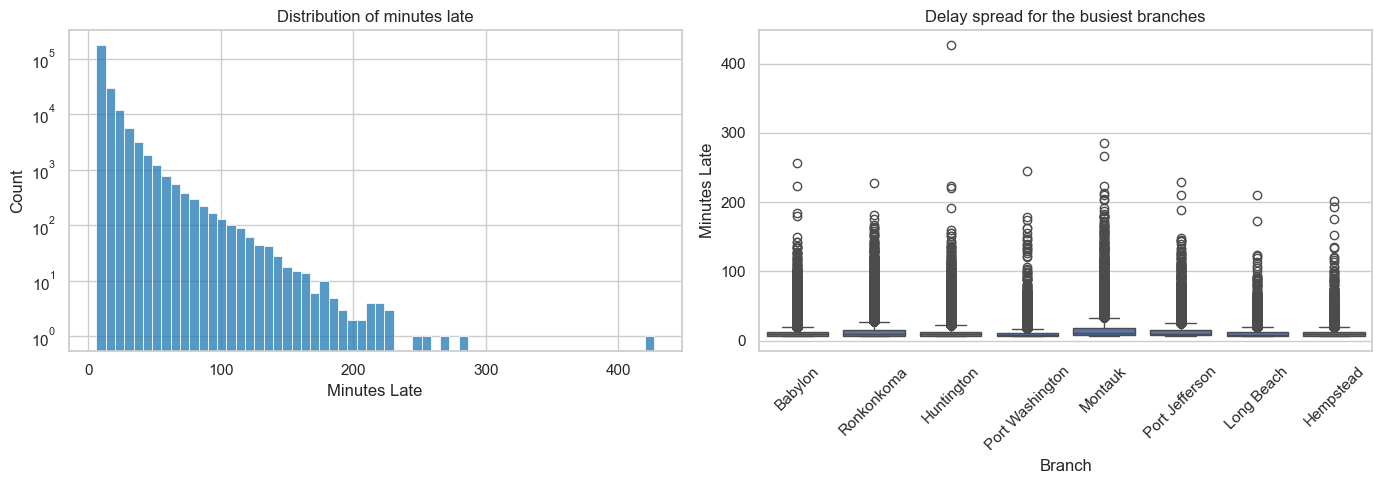

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=lirr_df,
    x='Minutes Late',
    bins=60,
    ax=axes[0],
    color='tab:blue',
)
axes[0].set_yscale("log") # Fixed the log scale so graph shows up
axes[0].set_title('Distribution of minutes late')
axes[0].set_xlabel('Minutes Late')

branch_order = (
    lirr_df['Branch']
    .value_counts()
    .nlargest(8)
    .index
)
sns.boxplot(
    data=lirr_df[lirr_df['Branch'].isin(branch_order)],
    x='Branch',
    y='Minutes Late',
    order=branch_order,
    ax=axes[1],
)
axes[1].set_title('Delay spread for the busiest branches')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()


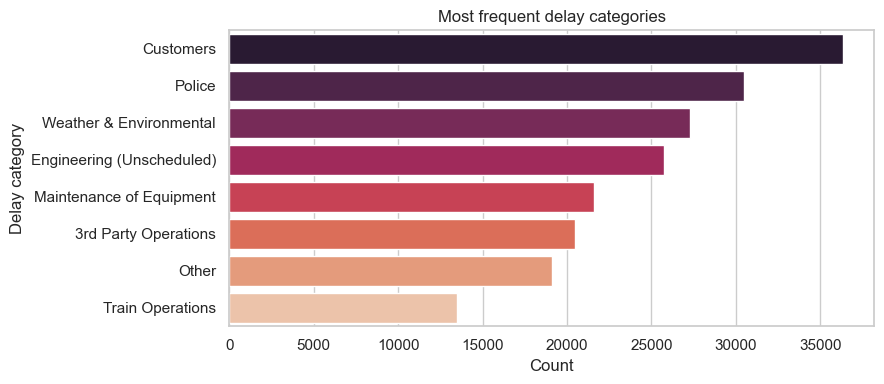

In [50]:
delay_category_counts = lirr_df['Delay Category'].value_counts().nlargest(8)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    x=delay_category_counts.values,
    y=delay_category_counts.index,
    hue=delay_category_counts.index,
    palette='rocket',
    ax=ax,
    legend=False,
)
ax.set_title('Most frequent delay categories')
ax.set_xlabel('Count')
ax.set_ylabel('Delay category')
plt.tight_layout()

## Temporal summaries (daily, weekday, monthly)
**Purpose:** capture day-to-day variability and longer-term patterns.
**How to read it:** weekday bars highlight routine schedule effects, while the monthly line plot shows seasonality or trend changes. Spikes in the monthly series can signal operational or weather-driven shifts.


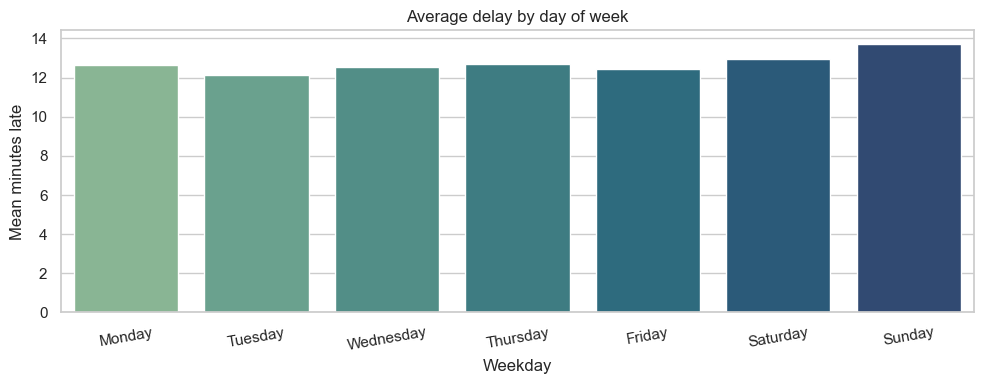

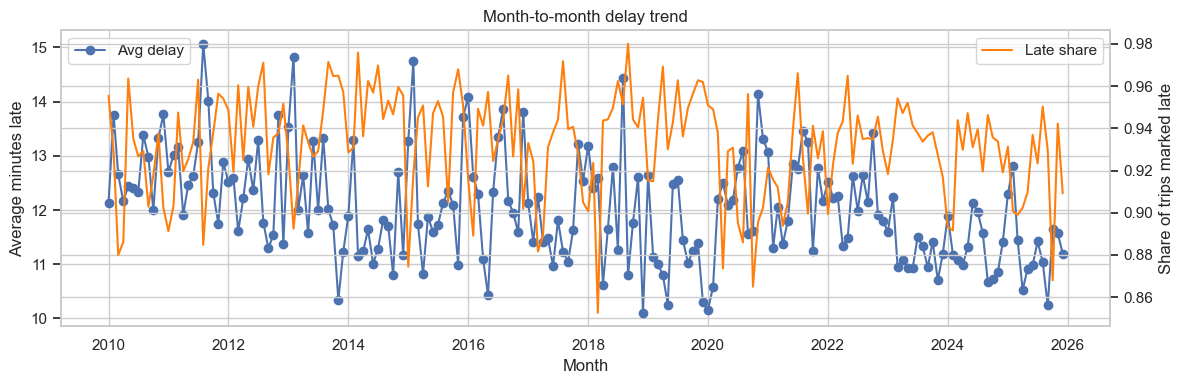

In [51]:
daily_summary = (
    lirr_df.groupby('date')
    .agg(
        total_trips=('Train', 'count'),
        avg_delay=('Minutes Late', 'mean'),
        median_delay=('Minutes Late', 'median'),
        late_trips=('is_late', 'sum'),
    )
    .assign(late_share=lambda df: df['late_trips'] / df['total_trips'])
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_summary = (
    lirr_df.groupby('weekday')
    .agg(avg_delay=('Minutes Late', 'mean'), late_share=('is_late', 'mean'))
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=weekday_summary.reset_index(),
    x='weekday',
    y='avg_delay',
    hue='weekday',
    palette='crest',
    ax=ax,
    legend=False,
)
ax.set_title('Average delay by day of week')
ax.set_ylabel('Mean minutes late')
ax.set_xlabel('Weekday')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()

monthly_summary = (
    daily_summary
    .reset_index()
    .assign(month=lambda df: df['date'].dt.to_period('M'))
    .groupby('month')
    .agg(avg_delay=('avg_delay', 'mean'), late_share=('late_share', 'mean'))
    .reset_index()
)
monthly_summary['month_start'] = monthly_summary['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_summary['month_start'], monthly_summary['avg_delay'], label='Avg delay', marker='o')
ax.set_title('Month-to-month delay trend')
ax.set_ylabel('Average minutes late')
ax2 = ax.twinx()
ax2.plot(
    monthly_summary['month_start'],
    monthly_summary['late_share'],
    label='Late share',
    color='tab:orange',
)
ax2.set_ylabel('Share of trips marked late')
ax.set_xlabel('Month')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()


## Temporal summaries (Holidays)
**Purpose:** Capture increased delays due to holidays and seasons.
**How to read it:** Average delay per week per year over an arbitrary calendar year

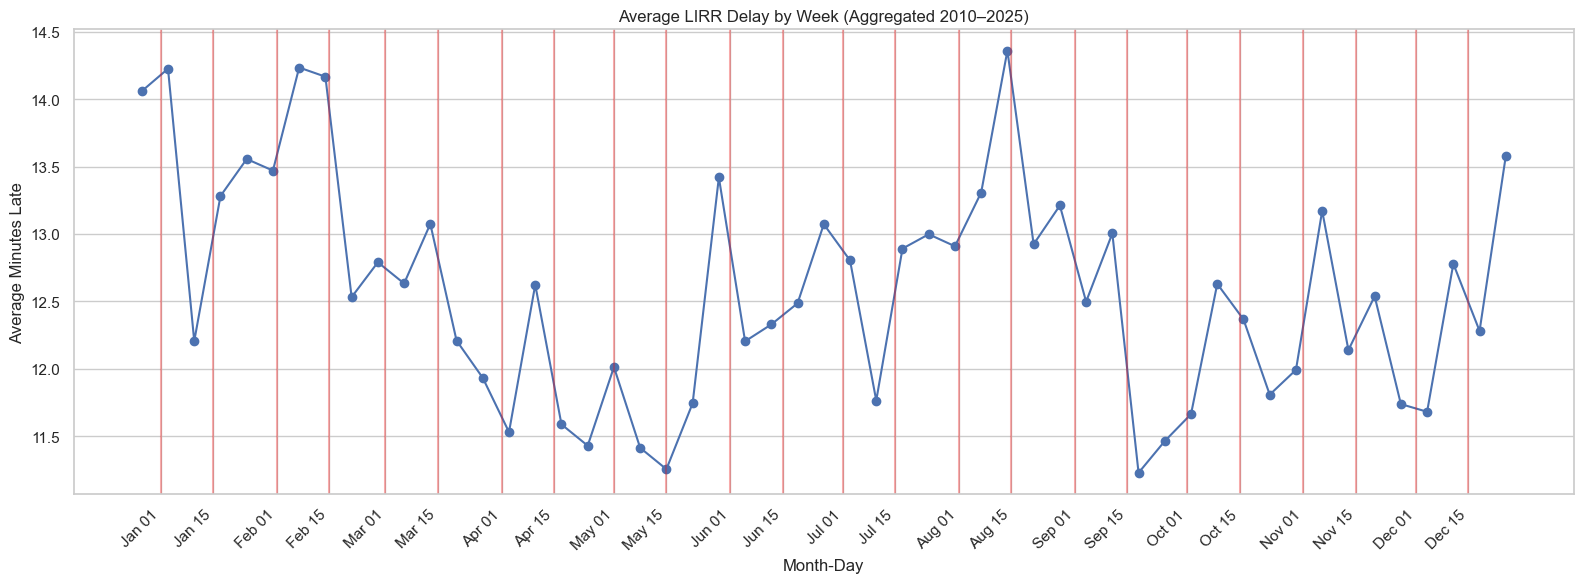

In [52]:
# Assign each date to its week in an arbitrary year (2000)
lirr_df['week_start'] = lirr_df['date'].apply(
    lambda d: pd.Timestamp(year=2000, month=d.month, day=d.day)
).dt.to_period('W').apply(lambda p: p.start_time)

# Aggregate weekly average delay across all years
weekly_avg = (
    lirr_df.groupby('week_start')
    .agg(avg_delay=('Minutes Late', 'mean'))
    .reset_index()
)

# Generate 1st and 15th of each month in year 2000
firsts = pd.date_range('2000-01-01', '2000-12-01', freq='MS')
fifteenths = firsts + pd.Timedelta(days=14)
marker_dates = firsts.union(fifteenths)

# Plot
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(weekly_avg['week_start'], weekly_avg['avg_delay'], marker='o', label='Avg Delay')

# Add vertical lines for 1st and 15th
for dt in marker_dates:
    ax.axvline(dt, color='red', alpha=0.3)

ax.set_title('Average LIRR Delay by Week (Aggregated 2010–2025)')
ax.set_xlabel('Month-Day')
ax.set_ylabel('Average Minutes Late')

# Optional: rotate x-axis labels
ax.set_xticks(marker_dates)
ax.set_xticklabels([dt.strftime('%b %d') for dt in marker_dates], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Weather highlights
**Purpose:** summarize the seasonal weather patterns that may affect service.
**How to read it:** compare temperature curves with precipitation totals. Large precipitation peaks or extreme temperature ranges suggest months that could plausibly increase delays.


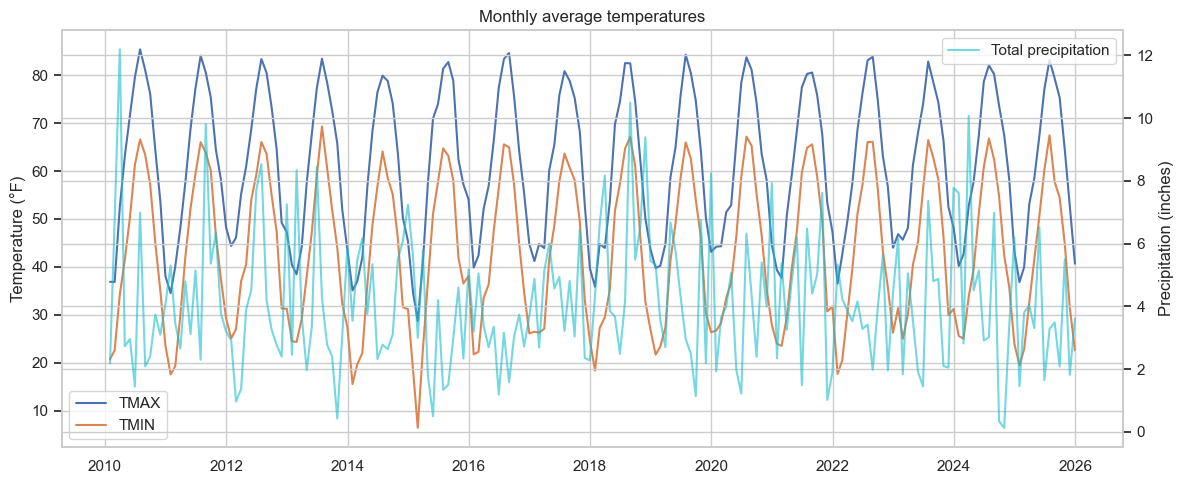

In [53]:
weather_monthly = (
    weather_df.set_index('DATE')
    .resample('ME')
    .agg(
        precipitation=('PRCP', 'sum'),
        tmax=('TMAX', 'mean'),
        tmin=('TMIN', 'mean'),
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weather_monthly.index, weather_monthly['tmax'], label='TMAX')
ax.plot(weather_monthly.index, weather_monthly['tmin'], label='TMIN')
ax.set_title('Monthly average temperatures')
ax.set_ylabel('Temperature (°F)')
ax.legend()
ax2 = ax.twinx()
ax2.plot(
    weather_monthly.index,
    weather_monthly['precipitation'],
    label='Total precipitation',
    color='tab:cyan',
    alpha=0.6,
)
ax2.set_ylabel('Precipitation (inches)')
ax2.legend(loc='upper right')
plt.tight_layout()


## Weather vs. delay relationships
**Purpose:** test whether delays rise in tandem with weather severity.
**How to read it:** the correlation heatmap provides a quick directional check, while the precipitation vs. delay plot shows if heavier rain corresponds to higher average delays. Weak or noisy relationships here imply weather may be only one of several drivers.


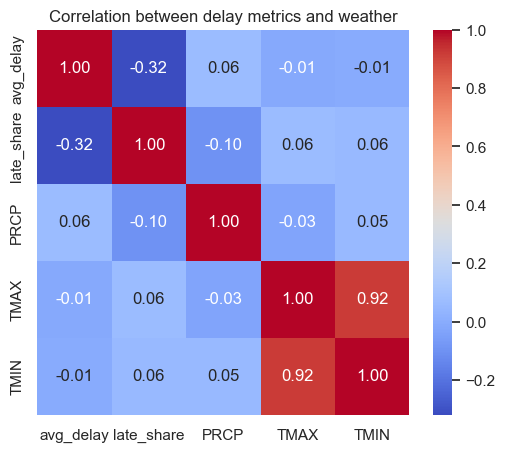

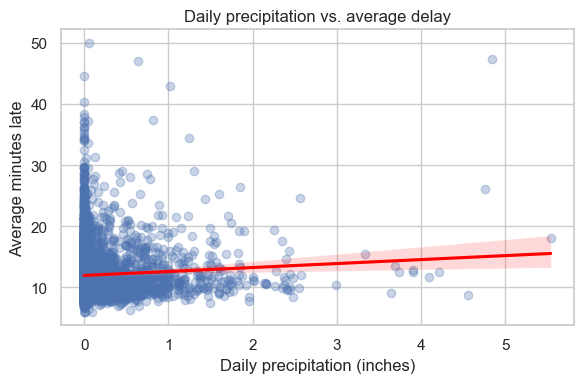

In [54]:
weather_daily = (
    weather_df.set_index('DATE')
    .resample('D')
    .agg(PRCP=('PRCP', 'sum'), TMAX=('TMAX', 'max'), TMIN=('TMIN', 'min'))
)

combined = (
    daily_summary
    .join(weather_daily, how='inner')
    .dropna(subset=['avg_delay', 'PRCP', 'TMAX', 'TMIN'])
)

corr = combined[['avg_delay', 'late_share', 'PRCP', 'TMAX', 'TMIN']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation between delay metrics and weather')

fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(
    data=combined,
    x='PRCP',
    y='avg_delay',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=ax,
)
ax.set_title('Daily precipitation vs. average delay')
ax.set_xlabel('Daily precipitation (inches)')
ax.set_ylabel('Average minutes late')
plt.tight_layout()

## Example of Clean Train Data

In [56]:
clean_lirr_df = pd.read_csv('../data/processed/lirr_train_clean_late.csv')

C:\Users\skylerturner\AppData\Local\Temp\ipykernel_14660\1812959986.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  clean_lirr_df = pd.read_csv('../data/processed/lirr_train_clean_late.csv')


dtype warning

In [ ]:
# Show all columns and their types
print(clean_lirr_df.dtypes)

service_date       object
train              object
branch             object
depart_station     object
depart_time        object
arrive_station     object
arrive_time        object
period             object
status             object
minutes_late      float64
delay_category     object
depart_dt          object
arrive_dt          object
hour                int64
dow                 int64
month               int64
is_weekend          int64
dtype: object


Can either drop unneeded columns or convert them

In [58]:
# Convert datetime columns
clean_lirr_df['depart_dt'] = pd.to_datetime(clean_lirr_df['depart_dt'], errors='coerce')
clean_lirr_df['arrive_dt'] = pd.to_datetime(clean_lirr_df['arrive_dt'], errors='coerce')
clean_lirr_df['service_date'] = pd.to_datetime(clean_lirr_df['service_date'], errors='coerce')
print(clean_lirr_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230029 entries, 0 to 230028
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   service_date    230029 non-null  datetime64[ns]
 1   train           230029 non-null  object        
 2   branch          230029 non-null  object        
 3   depart_station  230029 non-null  object        
 4   depart_time     230029 non-null  object        
 5   arrive_station  230029 non-null  object        
 6   arrive_time     230029 non-null  object        
 7   period          230029 non-null  object        
 8   status          230029 non-null  object        
 9   minutes_late    230029 non-null  float64       
 10  delay_category  230024 non-null  object        
 11  depart_dt       230029 non-null  datetime64[ns]
 12  arrive_dt       230029 non-null  datetime64[ns]
 13  hour            230029 non-null  int64         
 14  dow             230029 non-null  int

In [62]:
print(f'LIRR records:\n', lirr_df['Minutes Late'].describe())
print(f'\nClean LIRR records:\n', clean_lirr_df['minutes_late'].describe())

LIRR records:
 count     232463.0
mean     12.612291
std      11.302645
min            6.0
25%            7.0
50%            9.0
75%           13.0
max          427.0
Name: Minutes Late, dtype: Float64

Clean LIRR records:
 count    230029.000000
mean         12.447665
std          10.606267
min           6.000000
25%           7.000000
50%           9.000000
75%          13.000000
max         118.000000
Name: minutes_late, dtype: float64


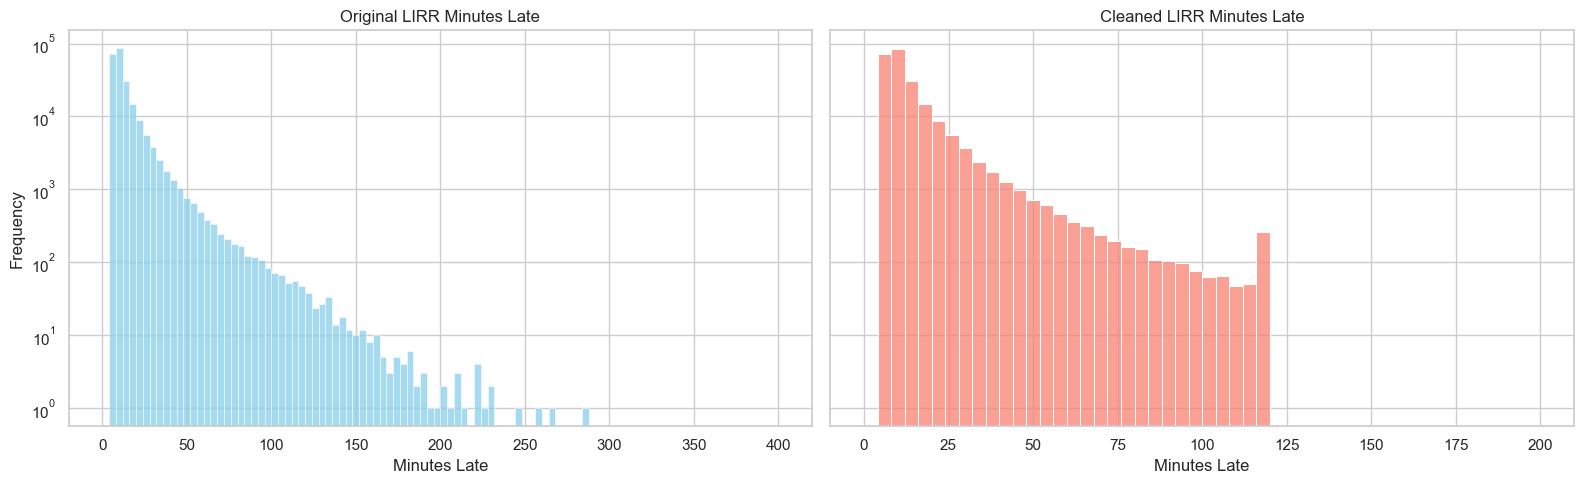

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Histogram for original LIRR dataset
sns.histplot(
    lirr_df['Minutes Late'],
    bins=100,
    binrange=(0, 400),
    color='skyblue',
    kde=False,
    ax=axes[0]
)
axes[0].set_yscale("log") # Fixed the log scale so graph shows up
axes[0].set_title('Original LIRR Minutes Late')
axes[0].set_xlabel('Minutes Late')
axes[0].set_ylabel('Frequency')

# Histogram for cleaned LIRR dataset
sns.histplot(
    clean_lirr_df['minutes_late'],
    bins=50,
    binrange=(0, 200),
    color='salmon',
    kde=False,
    ax=axes[1]
)
axes[1].set_yscale("log") # Fixed the log scale so graph shows up
axes[1].set_title('Cleaned LIRR Minutes Late')
axes[1].set_xlabel('Minutes Late')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [66]:
# Filter rows where Minutes Late < 6
small_delays = lirr_df[lirr_df['Minutes Late'] <= 6]
clean_small_delays = clean_lirr_df[clean_lirr_df['minutes_late'] <= 6]

# Print all values
print("Number of trips with Minutes Late < 6:", len(small_delays))
print("Number of clean trips with Minutes Late < 6:", len(clean_small_delays))

Number of trips with Minutes Late < 6: 32496
Number of clean trips with Minutes Late < 6: 32376
